In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loader

1. date: Date in format dd/mm/yyyy
2. time: time in format hh:mm:ss
3. global_active_power: household global minute-averaged active power (in kilowatt)
4. global_reactive_power: household global minute-averaged reactive power (in kilowatt)
5. voltage: minute-averaged voltage (in volt)
6. global_intensity: household global minute-averaged current intensity (in ampere)
7. sub_metering_1: energy sub-metering No. 1 (in watt-hour of active energy). It corresponds to the kitchen, containing mainly a dishwasher, an oven and a microwave (hot plates are not electric but gas powered).
8. sub_metering_2: energy sub-metering No. 2 (in watt-hour of active energy). It corresponds to the laundry room, containing a washing-machine, a tumble-drier, a refrigerator and a light.
9. sub_metering_3: energy sub-metering No. 3 (in watt-hour of active energy). It corresponds to an electric water-heater and an air-conditioner.

In [7]:
data_df = pd.read_csv(r"./household_power_consumption.txt", sep=';',
                       na_values=['?', ' ?'], low_memory=False)
print(data_df)

               Date      Time  Global_active_power  Global_reactive_power  \
0        16/12/2006  17:24:00                4.216                  0.418   
1        16/12/2006  17:25:00                5.360                  0.436   
2        16/12/2006  17:26:00                5.374                  0.498   
3        16/12/2006  17:27:00                5.388                  0.502   
4        16/12/2006  17:28:00                3.666                  0.528   
...             ...       ...                  ...                    ...   
2075254  26/11/2010  20:58:00                0.946                  0.000   
2075255  26/11/2010  20:59:00                0.944                  0.000   
2075256  26/11/2010  21:00:00                0.938                  0.000   
2075257  26/11/2010  21:01:00                0.934                  0.000   
2075258  26/11/2010  21:02:00                0.932                  0.000   

         Voltage  Global_intensity  Sub_metering_1  Sub_metering_2  \
0    

In [8]:
## Combine date and time to one column
data_df['datetime'] = pd.to_datetime(data_df["Date"] + ' ' + data_df["Time"],
                                     format="%d/%m/%Y %H:%M:%S", errors='coerce')

data_df = data_df.drop(columns=["Date", "Time"]).set_index("datetime").sort_index()

In [10]:
data_df = data_df.apply(pd.to_numeric, errors='coerce')

In [11]:
data_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [12]:
data_df.tail()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2010-11-26 20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2010-11-26 20:59:00,0.944,0.0,240.00,4.0,0.0,0.0,0.0
2010-11-26 21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2010-11-26 21:01:00,0.934,0.0,239.70,3.8,0.0,0.0,0.0
2010-11-26 21:02:00,0.932,0.0,239.55,3.8,0.0,0.0,0.0


In [13]:
data_df.shape

(2075259, 7)

In [14]:
data_df.size

14526813

In [15]:
data_df.dtypes

,0
Global_active_power,float64
Global_reactive_power,float64
Voltage,float64
Global_intensity,float64
Sub_metering_1,float64
Sub_metering_2,float64
Sub_metering_3,float64


In [16]:
data_df.info

<bound method DataFrame.info of                      Global_active_power  Global_reactive_power  Voltage  \
datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   
...                                  ...                    ...      ...   
2010-11-26 20:58:00                0.946                  0.000   240.43   
2010-11-26 20:59:00                0.944                  0.000   240.00   
2010-11-26 21:00:00                0.938                  0.000   239.82   
2010-11-26 21:01:00                0.934                  0.000   239.70   
2010-11-26 21:02:00                0.932                  0.000   239.55   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00              23.0             0.0             1.0   
2006-12-16 17:28:00              15.8             0.0             1.0   
...                               ...             ...             ...   
2010-11-26 20:58:00               4.0             0.0             0.0   
2010-11-26 20:59:00               4.0             0.0             0.0   
2010-11-26 21:00:00               3.8             0.0             0.0   
2010-11-26 21:01:00               3.8             0.0             0.0   
2010-11-26 21:02:00               3.8             0.0             0.0   

                     Sub_metering_3  
datetime                             
2006-12-16 17:24:00            17.0  
2006-12-16 17:25:00            16.0  
2006-12-16 17:26:00            17.0  
2006-12-16 17:27:00            17.0  
2006-12-16 17:28:00            17.0  
...                             ...  
2010-11-26 20:58:00             0.0  
2010-11-26 20:59:00             0.0  
2010-11-26 21:00:00             0.0  
2010-11-26 21:01:00             0.0  
2010-11-26 21:02:00             0.0  

[2075259 rows x 7 columns]>

In [17]:
data_df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


In [18]:
num_cols = data_df.select_dtypes(include='number').columns.to_list()
num_cols

['Global_active_power',
 'Global_reactive_power',
 'Voltage',
 'Global_intensity',
 'Sub_metering_1',
 'Sub_metering_2',
 'Sub_metering_3']

### Missing Value Analysis

In [20]:
data_df.isnull().sum()

,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


In [21]:
for i in data_df.columns:
    print(i, ':',  data_df[i].unique(), '\n')

Global_active_power : [4.216 5.36  5.374 ... 9.63  9.648 8.6  ] 

Global_reactive_power : [0.418 0.436 0.498 0.502 0.528 0.522 0.52  0.51  0.47  0.478 0.398 0.422
 0.282 0.152 0.156 0.    0.076 0.09  0.2   0.058 0.18  0.144 0.118 0.108
 0.202 0.192 0.186 0.116 0.136 0.148 0.16  0.158 0.1   0.082 0.05  0.052
 0.162 0.086 0.048 0.054 0.068 0.166 0.174 0.178 0.188 0.088 0.08  0.07
 0.084 0.074 0.106 0.092 0.064 0.046 0.138 0.134 0.132 0.12  0.13  0.154
 0.078 0.142 0.14  0.146 0.15  0.17  0.102 0.072 0.06  0.056 0.062 0.112
 0.066 0.172 0.168 0.194 0.184 0.096 0.164 0.182 0.094 0.098 0.176 0.19
 0.204 0.22  0.198 0.208 0.244 0.334 0.298 0.296 0.286 0.278 0.104 0.258
 0.238 0.256 0.214 0.23  0.21  0.24  0.124 0.122 0.27  0.302 0.272 0.25
 0.294 0.3   0.128 0.126 0.234 0.242 0.316 0.28  0.288 0.224 0.11  0.248
 0.254 0.222 0.246 0.216 0.212 0.114 0.206 0.228 0.226 0.196 0.218 0.368
 0.338 0.31  0.304 0.292 0.268 0.266 0.26  0.396 0.38  0.4   0.384 0.416
 0.404 0.382 0.232 0.314 0.312 0.262 

In [22]:
missing_pct = data_df.isnull().mean() * 100
missing_pct

,0
Global_active_power,1.251844
Global_reactive_power,1.251844
Voltage,1.251844
Global_intensity,1.251844
Sub_metering_1,1.251844
Sub_metering_2,1.251844
Sub_metering_3,1.251844


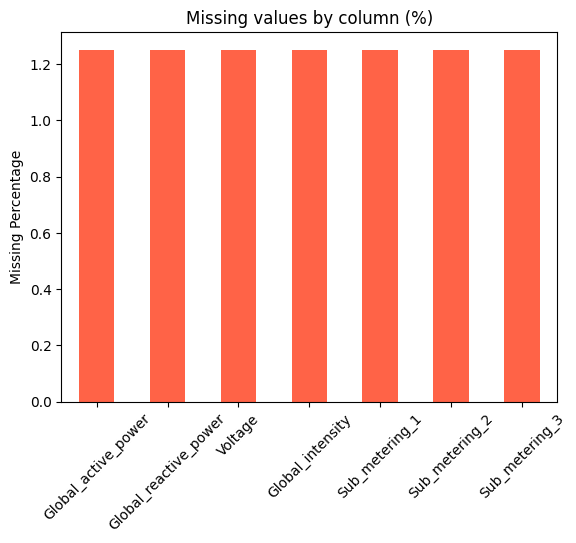

In [23]:
missing_pct.plot(kind='bar', color='tomato')
plt.title("Missing values by column (%)")
plt.ylabel("Missing Percentage")
plt.xticks(rotation=45)
plt.show()

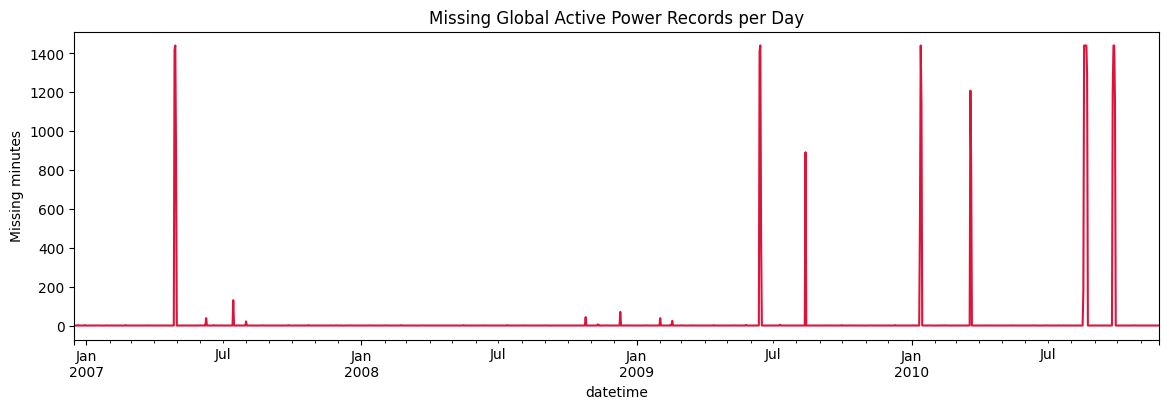

In [24]:
missing_by_day = data_df["Global_active_power"].isnull().resample("D").sum()

plt.figure(figsize=(14, 4))
missing_by_day.plot(color="crimson")
plt.title("Missing Global Active Power Records per Day")
plt.ylabel("Missing minutes")
plt.show()

create an hourly dataset; it reduces noise and makes plots much faster.

In [25]:
hourly = data_df.resample("h").mean()

# Remove hours where all measurements are missing
hourly = hourly.dropna(how="all")

# Interpolate small gaps only
hourly = hourly.interpolate(method="time", limit=3)

hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [27]:
# ### Fixing null values
num_cols_null = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity',
                'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

data_df[num_cols_null] = data_df[num_cols_null].fillna(data_df[num_cols_null].median())

In [28]:
data_df.isnull().sum()

,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


### Relation among numeric data

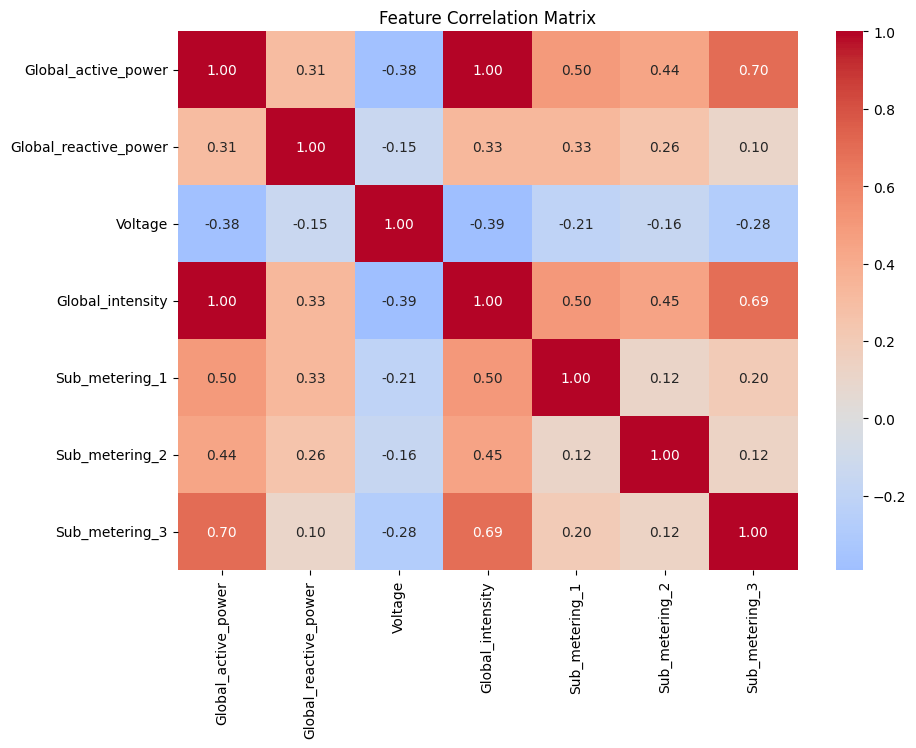

In [36]:
power_columns = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]
corr = hourly[power_columns].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

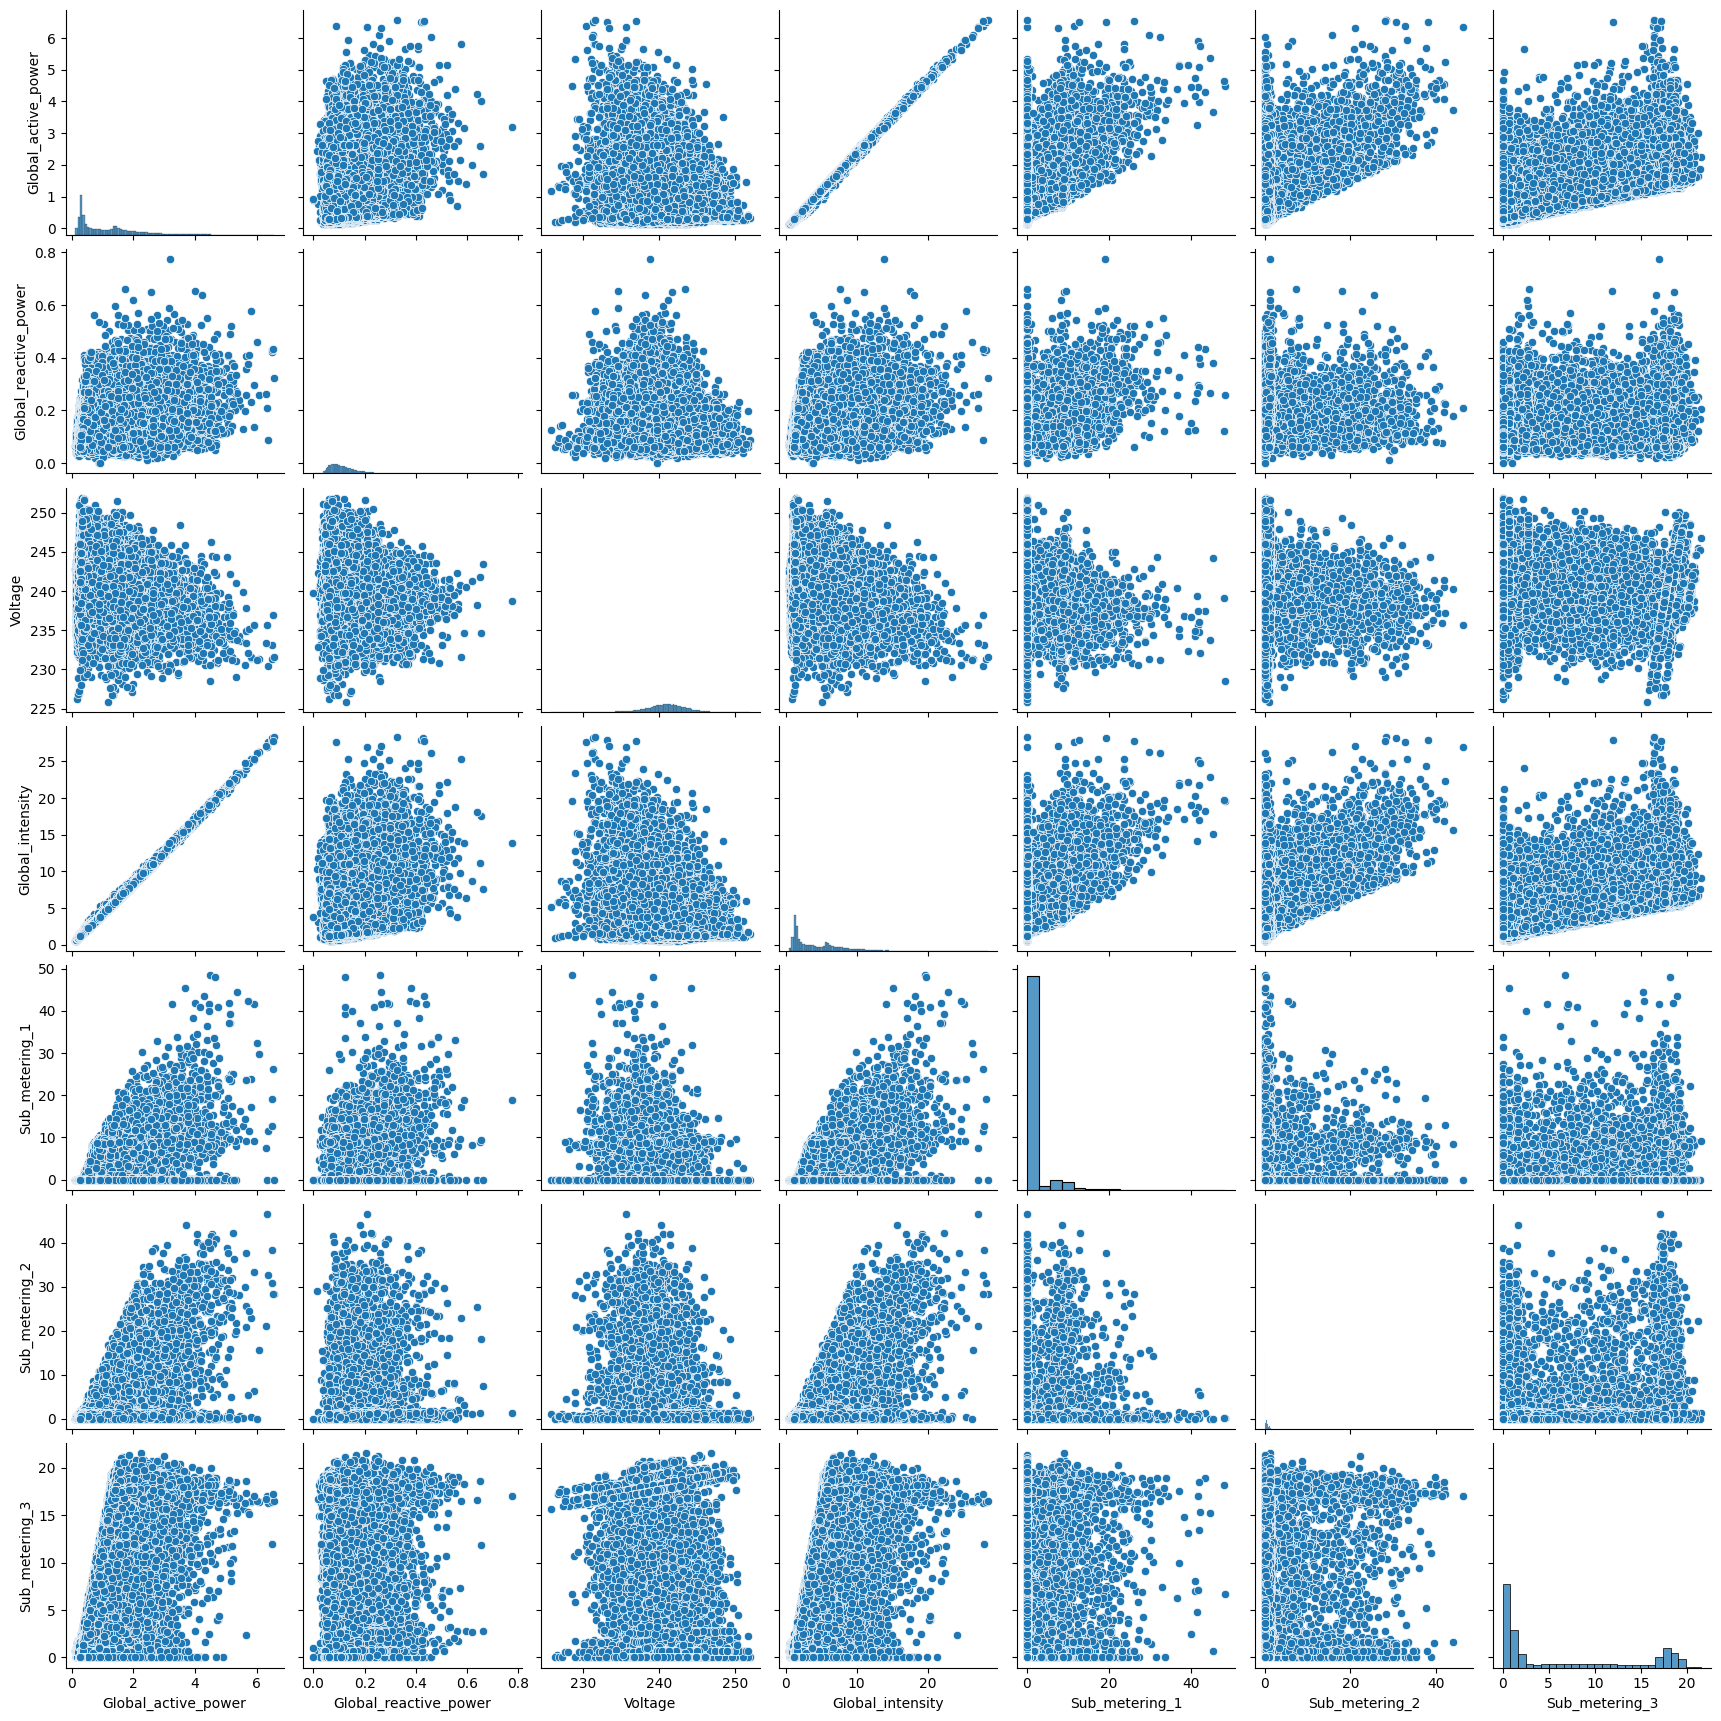

In [38]:
sns.pairplot(hourly[power_columns])
plt.show()

######## *** (All optional) If you want more in-depth relation between the numeric data ***

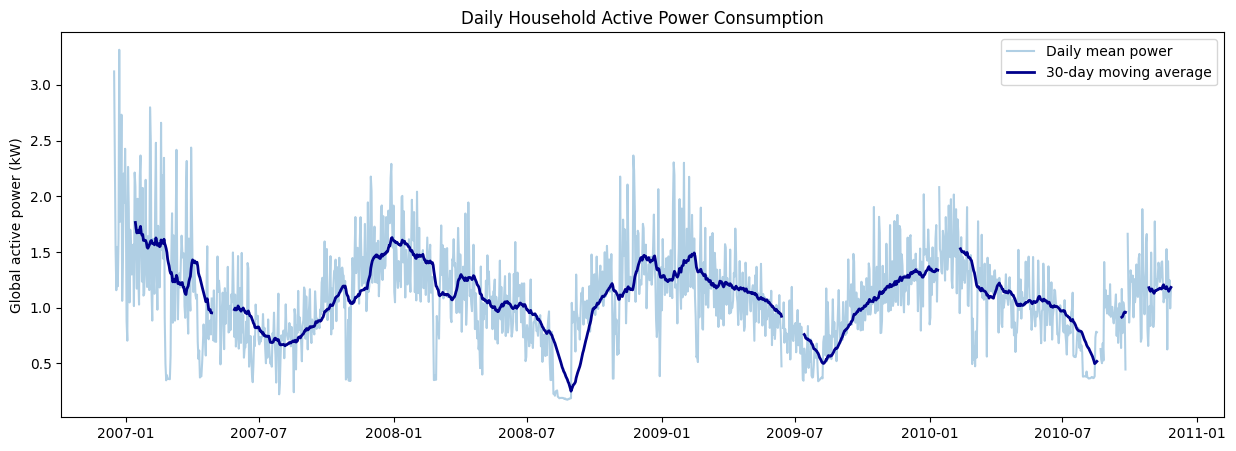

In [30]:
daily_power = hourly["Global_active_power"].resample("D").mean()
rolling_30d = daily_power.rolling(30).mean()

plt.figure(figsize=(15, 5))
plt.plot(daily_power, alpha=0.35, label="Daily mean power")
plt.plot(rolling_30d, linewidth=2, color="darkblue", label="30-day moving average")
plt.title("Daily Household Active Power Consumption")
plt.ylabel("Global active power (kW)")
plt.legend()
plt.show()

In [32]:
# UCI formula: active energy not captured by the three submeters
hourly["Other_energy_wh"] = (
    hourly["Global_active_power"] * 1000 / 60
    - hourly["Sub_metering_1"]
    - hourly["Sub_metering_2"]
    - hourly["Sub_metering_3"]
)

# Calendar fields
hourly["hour"] = hourly.index.hour
hourly["day_of_week"] = hourly.index.day_name()
hourly["month"] = hourly.index.month_name()
hourly["is_weekend"] = hourly.index.dayofweek >= 5

# Guard against tiny negative values caused by rounding
hourly["Other_energy_wh"] = hourly["Other_energy_wh"].clip(lower=0)

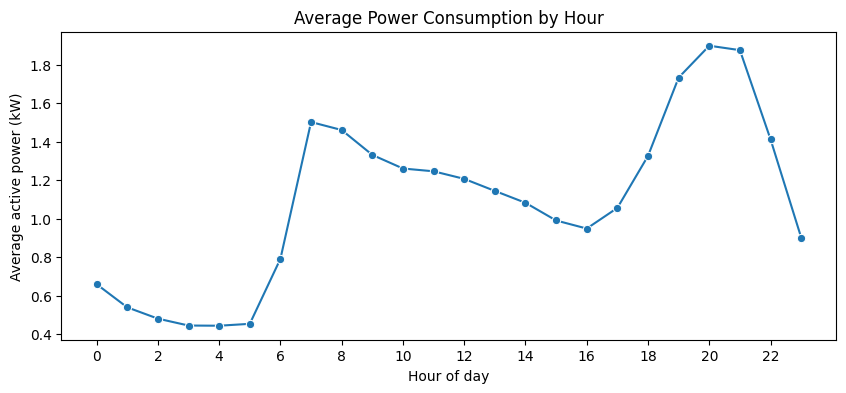

In [33]:
### Typical consumption by hour of day
hourly_profile = hourly.groupby("hour")["Global_active_power"].mean()

plt.figure(figsize=(10, 4))
sns.lineplot(x=hourly_profile.index, y=hourly_profile.values, marker="o")
plt.title("Average Power Consumption by Hour")
plt.xlabel("Hour of day")
plt.ylabel("Average active power (kW)")
plt.xticks(range(0, 24, 2))
plt.show()

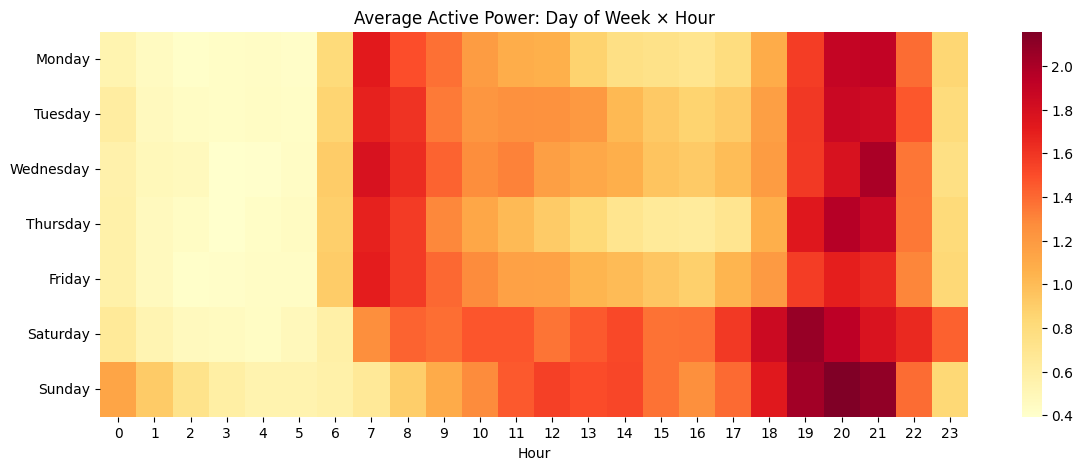

In [34]:
### Hour x Day-of-Week
day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]
heatmap_data = (
    hourly.groupby(["day_of_week", "hour"])["Global_active_power"]
    .mean()
    .unstack()
    .reindex(day_order)
)
plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap="YlOrRd")
plt.title("Average Active Power: Day of Week × Hour")
plt.xlabel("Hour")
plt.ylabel("")
plt.show()

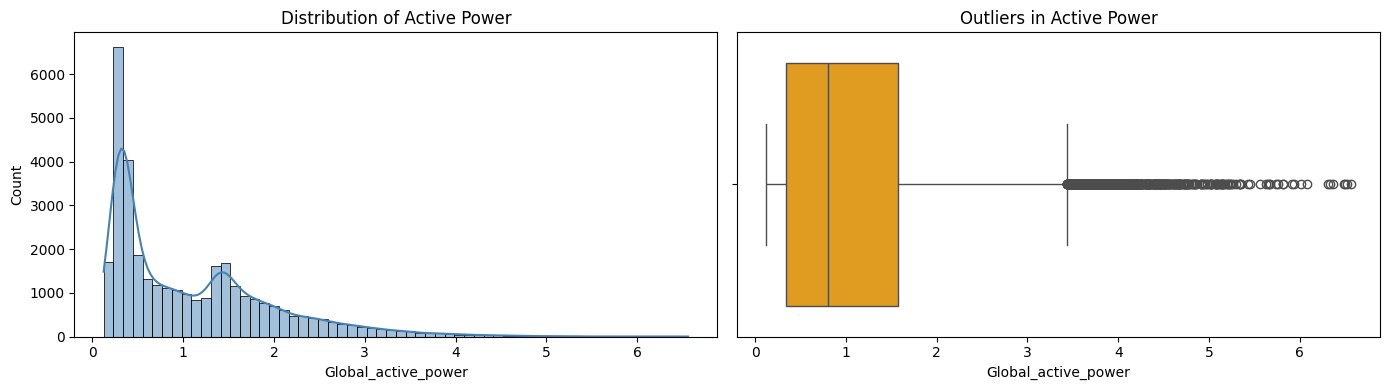

In [40]:
### Outliers and Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(
    hourly["Global_active_power"].dropna(),
    bins=60,
    kde=True,
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Distribution of Active Power")

sns.boxplot(
    x=hourly["Global_active_power"].dropna(),
    ax=axes[1],
    color="orange"
)
axes[1].set_title("Outliers in Active Power")
plt.tight_layout()
plt.show()